# Лабораторна робота № 3
## Побудова та оцінювання моделі лінійної регресії

**Мета:** Набути практичних навичок розв'язання задачі регресії; навчитися відокремлювати ознаки від цільової змінної, запобігати витоку даних, розділяти вибірку на навчальну і тестову частини, порівнювати модель із базовим прогнозом та інтерпретувати МАЕ, RMSE і коефіцієнт детермінації $R^2$.

**Студентка:** Кичата Софія Володимирівна   
**Група:** МІТ-31
**Номер у списку (random_state):** 11

**Набір даних:** Medical Cost Personal Datasets (Прогнозування медичних витрат).
**Цільова змінна:** `charges` (індивідуальні медичні витрати, які оплачуються медичним страхуванням).
**Джерело:** Відкритий датасет (Kaggle / GitHub raw link). Ліцензія: Open Data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Фіксуємо random_state згідно з номером у списку
seed = 11

In [2]:
# Завантаження даних (використовуємо пряме посилання на CSV)
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# Визначаємо цільову змінну (y) та ознаки (X)
target_col = 'charges'
X = df.drop(columns=[target_col])
y = df[target_col]

print("Дані успішно завантажено. Формат ознак Х:", X.shape)

Дані успішно завантажено. Формат ознак Х: (1338, 6)


In [3]:
print("--- Первинний аналіз даних ---")
print(f"Shape: {df.shape}")
print("\nDtypes:\n", df.dtypes)
print("\nInfo:")
df.info()

print("\nОписова статистика (describe):\n", df.describe())

print("\nКількість пропусків:\n", df.isna().sum())
print(f"\nКількість дублікатів: {df.duplicated().sum()}")

# Очищення від дублікатів (якщо є)
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    X = df.drop(columns=[target_col])
    y = df[target_col]
    print(f"Дублікати видалено. Новий shape: {df.shape}")

--- Первинний аналіз даних ---
Shape: (1338, 7)

Dtypes:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB

Описова статистика (describe):
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min    

In [4]:
# Розділення на train і test (80/20) із фіксованим random_state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

print(f"Розмір навчальної вибірки (train): {X_train.shape}")
print(f"Розмір тестової вибірки (test): {X_test.shape}")

Розмір навчальної вибірки (train): (1069, 6)
Розмір тестової вибірки (test): (268, 6)


In [5]:
# Автоматичне визначення числових та категоріальних колонок
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Конвеєр для числових ознак (заповнення пропусків медіаною)
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# Конвеєр для категоріальних ознак (заповнення найчастішим і OneHotEncoder)
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Об'єднання в ColumnTransformer
preprocessing = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
])

# Базова модель (DummyRegressor)
dummy_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", DummyRegressor(strategy="mean"))
])

# Основна модель (Лінійна регресія)
model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", LinearRegression())
])

C:\Temp\ipykernel_16568\854917828.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


In [6]:
# Навчання моделей ТІЛЬКИ на навчальній вибірці (train)
dummy_model.fit(X_train, y_train)
model.fit(X_train, y_train)

# Отримання прогнозів на тестовій вибірці (test)
y_pred_dummy = dummy_model.predict(X_test)
y_pred_model = model.predict(X_test)

print("Навчання та прогнозування завершено.")

Навчання та прогнозування завершено.


In [7]:
# Метрики для базової моделі (Dummy)
mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = mean_squared_error(y_test, y_pred_dummy) ** 0.5
r2_dummy = r2_score(y_test, y_pred_dummy)

# Метрики для основної моделі (Linear Regression)
mae_model = mean_absolute_error(y_test, y_pred_model)
rmse_model = mean_squared_error(y_test, y_pred_model) ** 0.5
r2_model = r2_score(y_test, y_pred_model)

# Порівняльна таблиця метрик
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Dummy Regressor (Baseline)': [mae_dummy, rmse_dummy, r2_dummy],
    'Linear Regression': [mae_model, rmse_model, r2_model]
})

print("--- Порівняння моделей ---")
display(metrics_df)

--- Порівняння моделей ---


,Metric,Dummy Regressor (Baseline),Linear Regression
0,MAE,8954.987321,3644.249914
1,RMSE,11537.428521,4936.382902
2,R2 Score,-0.015329,0.814131


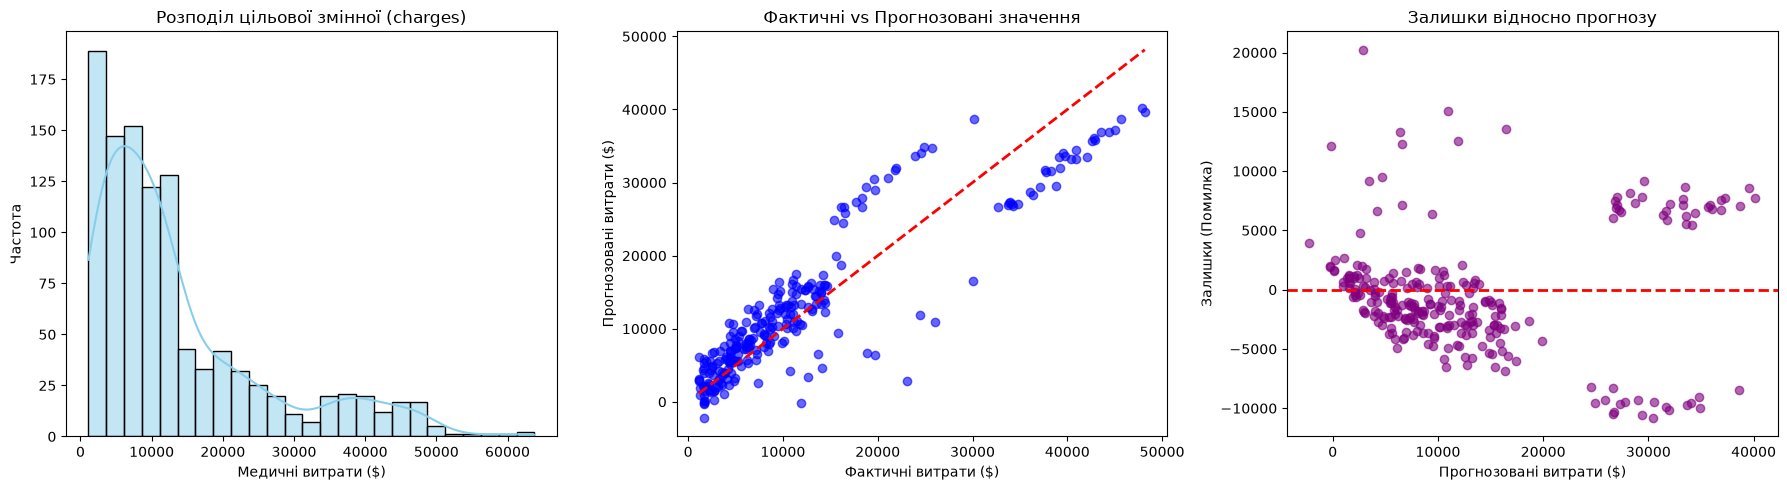

In [8]:
# Налаштування графіків
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Розподіл цілі (y_train)
sns.histplot(y_train, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Розподіл цільової змінної (charges)')
axes[0].set_xlabel('Медичні витрати ($)')
axes[0].set_ylabel('Частота')

# 2. Фактичні значення проти прогнозованих
axes[1].scatter(y_test, y_pred_model, alpha=0.6, color='blue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Фактичні vs Прогнозовані значення')
axes[1].set_xlabel('Фактичні витрати ($)')
axes[1].set_ylabel('Прогнозовані витрати ($)')

# 3. Залишки відносно прогнозу
residuals = y_test - y_pred_model
axes[2].scatter(y_pred_model, residuals, alpha=0.6, color='purple')
axes[2].axhline(y=0, color='r', linestyle='--', lw=2)
axes[2].set_title('Залишки відносно прогнозу')
axes[2].set_xlabel('Прогнозовані витрати ($)')
axes[2].set_ylabel('Залишки (Помилка)')

plt.tight_layout()
plt.savefig('Lab3_plots.png', dpi=300)
plt.show()

**Інтерпретація результатів:**
1. Наша лінійна регресійна модель значно перевершує базову модель (Dummy Regressor), оскільки її помилки MAE та RMSE істотно нижчі, а $R^2$ додатний (показує, яку частку мінливості цілі пояснює модель).
2. На графіку фактичних значень проти прогнозованих видно, що точки вишиковуються вздовж ідеальної червоної лінії, проте є група спостережень (витрати понад 30-40 тисяч), де модель системно занижує прогноз.
3. Графік залишків показує наявність певної структури (візуально виділяються кластери замість рівномірного випадкового розкиду). Це свідчить про те, що лінійна залежність не ідеально описує дані, і можливо, є приховані нелінійні фактори (наприклад, курці з високим ІМТ генерують екстремальні витрати).

In [9]:
# Збереження прогнозів
test_predictions = pd.DataFrame({
    'Actual_Charges': y_test,
    'Predicted_Charges': y_pred_model,
    'Residuals': residuals
})
test_predictions.to_csv('test_predictions.csv', index=False)

# Збереження метрик
metrics_df.to_csv('metrics.csv', index=False)

print("Файли test_predictions.csv та metrics.csv успішно збережено!")

Файли test_predictions.csv та metrics.csv успішно збережено!
